<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

In [195]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
car_insurance = pd.read_csv("car_insurance.csv")

# View the dataset
car_insurance.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


### Data preprocessing 

In [196]:
car_insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

In [197]:
# checking missing data
print(car_insurance.isna().sum().sort_values())

id                       0
duis                     0
speeding_violations      0
vehicle_type             0
postal_code              0
children                 0
married                  0
past_accidents           0
vehicle_year             0
income                   0
education                0
driving_experience       0
gender                   0
age                      0
vehicle_ownership        0
outcome                  0
annual_mileage         957
credit_score           982
dtype: int64


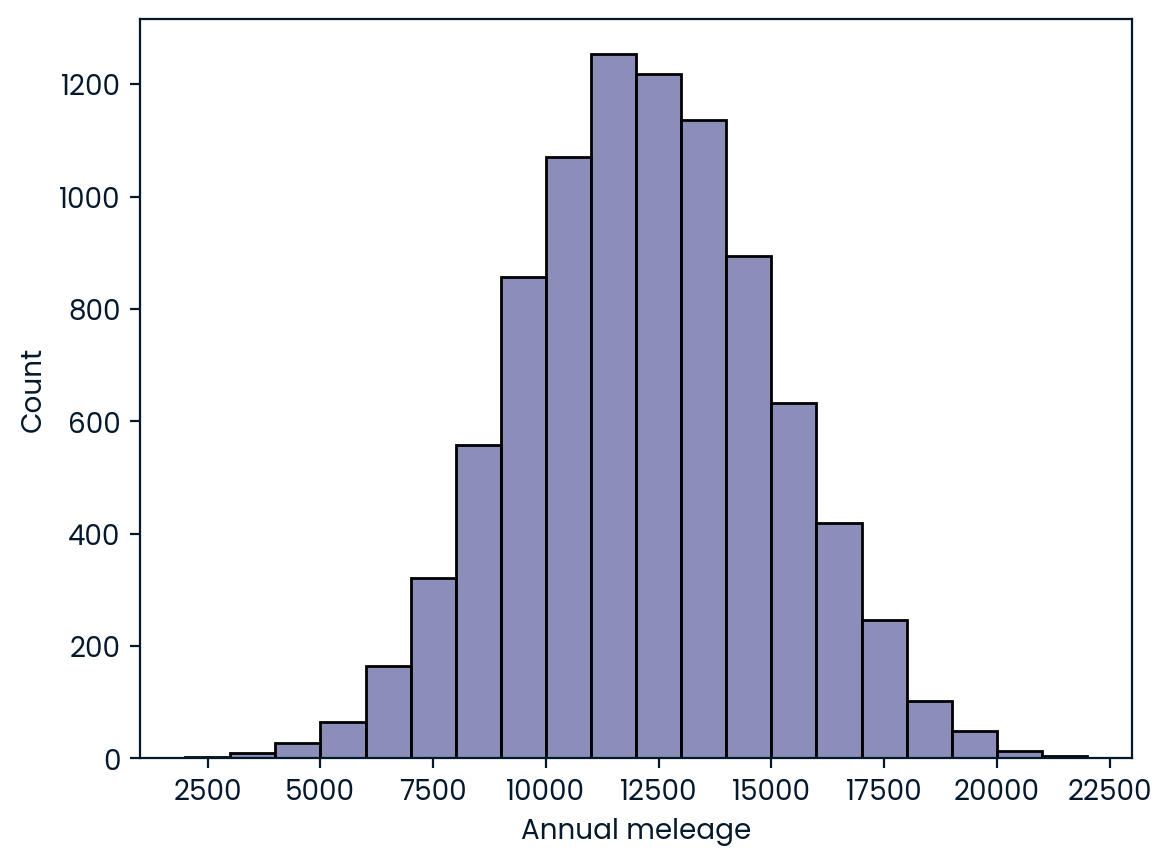

In [198]:
sns.histplot(data=car_insurance, x='annual_mileage', bins=20)

plt.xlabel('Annual meleage')
plt.ylabel('Count')
plt.show()

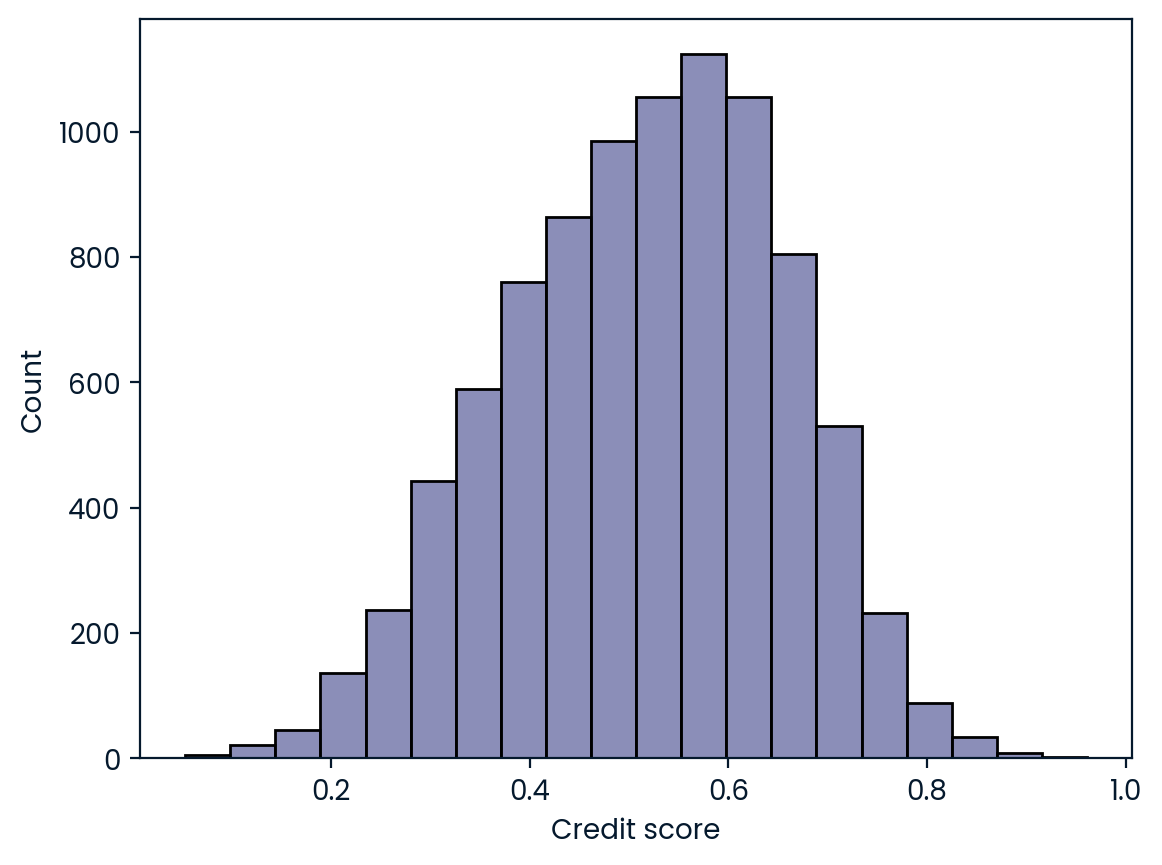

In [199]:
sns.histplot(data=car_insurance, x='credit_score', bins=20)

plt.xlabel('Credit score')
plt.ylabel('Count')
plt.show()

In [200]:
# filling missing data with mean() and median()
car_insurance["annual_mileage"].fillna(car_insurance["annual_mileage"].mean(), inplace=True)
car_insurance["credit_score"].fillna(car_insurance["credit_score"].mean(), inplace=True)

In [201]:
# checking missing data
print(car_insurance.isna().sum().sort_values())

id                     0
duis                   0
speeding_violations    0
vehicle_type           0
annual_mileage         0
postal_code            0
children               0
married                0
vehicle_year           0
vehicle_ownership      0
credit_score           0
income                 0
education              0
driving_experience     0
gender                 0
age                    0
past_accidents         0
outcome                0
dtype: int64


In [202]:
# Let's convert outcome column from float64 to int64 forman
car_insurance["outcome"] = car_insurance["outcome"].astype("int64")

### 1. Identify the single feature of the data that is the best predictor of whether a customer will put in a claim (the "outcome" column), excluding the "id" column

In [203]:
correlations = car_insurance.corr(numeric_only=True)
print(correlations["outcome"].sort_values(ascending=False))


outcome                1.000000
annual_mileage         0.177575
gender                 0.107208
postal_code            0.095889
id                    -0.010506
duis                  -0.189352
children              -0.232835
married               -0.262104
speeding_violations   -0.291862
credit_score          -0.309010
past_accidents        -0.311495
vehicle_ownership     -0.378921
age                   -0.448463
Name: outcome, dtype: float64


In [204]:
correlations_with_target = correlations["outcome"].drop("outcome")
best_corr_feature = correlations_with_target.abs().idxmax()
best_corr_value = correlations_with_target[best_corr_feature]

print(f"Best numeric predictor of 'outcome' is '{best_corr_feature}' with correlation {best_corr_value:.4f}")

Best numeric predictor of 'outcome' is 'age' with correlation -0.4485


### 2. Store as a DataFrame called best_feature_df, containing columns named "best_feature" and "best_accuracy" with the name of the feature with the highest accuracy, and the respective accuracy score.

In [205]:
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit

# 1. Define features (exclude 'outcome' and 'id') and target
features = car_insurance.drop(['outcome', 'id'], axis=1).columns

# 2. Create lists to store models results
models = []

# 3. Loop over each feature and build a logistic regression model
for col in features:
    # Create a model
    model = logit(f"outcome ~ {col}", data=car_insurance).fit(disp=False)
    # Add each model to the models list
    models.append(model)

# Empty list to store accuracies
accuracies = []

# Loop through models
for feature in range(0, len(models)):
    # Compute the confusion matrix
    conf_matrix = models[feature].pred_table()

    # Extract confusion matrix values
    tn = conf_matrix[0, 0]
    fp = conf_matrix[0, 1]
    fn = conf_matrix[1, 0]
    tp = conf_matrix[1, 1]

    # Calculate accuracy and store it
    acc = (tn + tp) / (tn + fp + fn + tp)
    accuracies.append(acc)

# 4. Identify the best-performing feature
best_feature = features[accuracies.index(max(accuracies))]

# 5. Create a DataFrame to show the result
best_feature_df = pd.DataFrame({
    "best_feature": best_feature,
    "best_accuracy": max(accuracies)}, index=[0])

# Print the result
print(best_feature_df)

         best_feature  best_accuracy
0  driving_experience         0.7771
